<a href="https://colab.research.google.com/github/kb0417/french-ewe-translation-transcription/blob/main/notebooks/04_seq2seq_lstm_ewe_to_french.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 04 — Modèle Seq2Seq LSTM pour la traduction éwé → français

Dans ce notebook, nous construisons un deuxième modèle de traduction automatique, cette fois dans le sens éwé vers français.

Dans le notebook précédent, nous avons entraîné un premier modèle pour traduire du français vers l’éwé.  
Ici, nous réutilisons les données prétraitées déjà sauvegardées dans Google Drive afin d'entraîner un modèle inverse.

L’objectif est de permettre au système de fonctionner dans les deux directions :

- français → éwé ;
- éwé → français.

Le modèle utilisé reste une architecture Seq2Seq basée sur des LSTM.  
Cela nous permet de garder une approche cohérente avec le premier modèle et de comparer les résultats obtenus dans les deux sens.

In [1]:

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# On importe les bibliothèques nécessaires.
#
# numpy sert à charger les fichiers .npy générés lors du prétraitement.
# pickle permet de recharger les tokenizers et la configuration.
# TensorFlow/Keras est utilisé pour construire et entraîner le modèle Seq2Seq.

import os
import pickle
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Embedding, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [3]:
# On définit les chemins principaux du projet.
#
# project_dir correspond au dossier racine du projet dans Google Drive.
# preprocessing_dir contient les fichiers .npy, les tokenizers et la configuration.
# models_dir contiendra les modèles entraînés.

project_dir = "/content/drive/MyDrive/french_ewe_project"
preprocessing_dir = os.path.join(project_dir, "artifacts/preprocessing")
models_dir = os.path.join(project_dir, "models")

print("Dossier projet :", project_dir)
print("Dossier preprocessing :", preprocessing_dir)
print("Dossier modèles :", models_dir)

Dossier projet : /content/drive/MyDrive/french_ewe_project
Dossier preprocessing : /content/drive/MyDrive/french_ewe_project/artifacts/preprocessing
Dossier modèles : /content/drive/MyDrive/french_ewe_project/models


In [4]:
# On vérifie rapidement le contenu du dossier de prétraitement.
# Cela permet de s'assurer que les fichiers nécessaires sont bien disponibles.

print(os.listdir(preprocessing_dir))

['X_train_fr_pad.npy', 'decoder_input_train_ewe.npy', 'decoder_target_train_ewe.npy', 'X_valid_fr_pad.npy', 'decoder_input_valid_ewe.npy', 'decoder_target_valid_ewe.npy', 'X_test_fr_pad.npy', 'decoder_input_test_ewe.npy', 'decoder_target_test_ewe.npy', 'X_train_ewe_pad.npy', 'decoder_input_train_fr.npy', 'decoder_target_train_fr.npy', 'X_valid_ewe_pad.npy', 'decoder_input_valid_fr.npy', 'decoder_target_valid_fr.npy', 'X_test_ewe_pad.npy', 'decoder_input_test_fr.npy', 'decoder_target_test_fr.npy', 'french_tokenizer.pkl', 'ewe_tokenizer.pkl', 'preprocessing_config.pkl']


In [5]:
# Pour le modèle éwé → français :
#
# - X_train_ewe contient les phrases éwé en entrée de l'encodeur ;
# - decoder_input_train_fr contient les phrases françaises décalées données au décodeur ;
# - decoder_target_train_fr contient les mots français que le modèle doit prédire.
#
# On charge aussi les ensembles de validation et de test.

X_train_ewe = np.load(os.path.join(preprocessing_dir, "X_train_ewe_pad.npy"))
decoder_input_train_fr = np.load(os.path.join(preprocessing_dir, "decoder_input_train_fr.npy"))
decoder_target_train_fr = np.load(os.path.join(preprocessing_dir, "decoder_target_train_fr.npy"))

X_valid_ewe = np.load(os.path.join(preprocessing_dir, "X_valid_ewe_pad.npy"))
decoder_input_valid_fr = np.load(os.path.join(preprocessing_dir, "decoder_input_valid_fr.npy"))
decoder_target_valid_fr = np.load(os.path.join(preprocessing_dir, "decoder_target_valid_fr.npy"))

X_test_ewe = np.load(os.path.join(preprocessing_dir, "X_test_ewe_pad.npy"))
decoder_input_test_fr = np.load(os.path.join(preprocessing_dir, "decoder_input_test_fr.npy"))
decoder_target_test_fr = np.load(os.path.join(preprocessing_dir, "decoder_target_test_fr.npy"))

In [6]:
# On vérifie les dimensions des tableaux.
# Les entrées encodeur et décodeur doivent avoir le même nombre d'exemples.

print("X_train_ewe :", X_train_ewe.shape)
print("decoder_input_train_fr :", decoder_input_train_fr.shape)
print("decoder_target_train_fr :", decoder_target_train_fr.shape)

print("\nX_valid_ewe :", X_valid_ewe.shape)
print("decoder_input_valid_fr :", decoder_input_valid_fr.shape)
print("decoder_target_valid_fr :", decoder_target_valid_fr.shape)

print("\nX_test_ewe :", X_test_ewe.shape)
print("decoder_input_test_fr :", decoder_input_test_fr.shape)
print("decoder_target_test_fr :", decoder_target_test_fr.shape)

X_train_ewe : (18820, 50)
decoder_input_train_fr : (18820, 49)
decoder_target_train_fr : (18820, 49)

X_valid_ewe : (2352, 50)
decoder_input_valid_fr : (2352, 49)
decoder_target_valid_fr : (2352, 49)

X_test_ewe : (2353, 50)
decoder_input_test_fr : (2353, 49)
decoder_target_test_fr : (2353, 49)


In [7]:
# On recharge les tokenizers et la configuration créés dans le notebook 02.
#
# Le tokenizer éwé sert pour l'entrée du modèle.
# Le tokenizer français sert pour la sortie du modèle.

with open(os.path.join(preprocessing_dir, "ewe_tokenizer.pkl"), "rb") as f:
    ewe_tokenizer = pickle.load(f)

with open(os.path.join(preprocessing_dir, "french_tokenizer.pkl"), "rb") as f:
    french_tokenizer = pickle.load(f)

with open(os.path.join(preprocessing_dir, "preprocessing_config.pkl"), "rb") as f:
    config = pickle.load(f)

config

{'VOCAB_SIZE': 10000,
 'french_vocab_size': 10000,
 'ewe_vocab_size': 10000,
 'MAX_LEN_FRENCH': 50,
 'MAX_LEN_EWE': 50}

In [8]:
# On récupère les paramètres importants.
# Ils doivent être identiques à ceux utilisés pendant le prétraitement.

ewe_vocab_size = config["ewe_vocab_size"]
french_vocab_size = config["french_vocab_size"]

MAX_LEN_EWE = config["MAX_LEN_EWE"]
MAX_LEN_FRENCH = config["MAX_LEN_FRENCH"]

print("Vocabulaire éwé :", ewe_vocab_size)
print("Vocabulaire français :", french_vocab_size)
print("Longueur max éwé :", MAX_LEN_EWE)
print("Longueur max français :", MAX_LEN_FRENCH)

Vocabulaire éwé : 10000
Vocabulaire français : 10000
Longueur max éwé : 50
Longueur max français : 50


In [9]:
# Pour utiliser sparse_categorical_crossentropy,
# les sorties attendues doivent avoir une dimension finale supplémentaire.
#
# La fonction ci-dessous évite d'ajouter cette dimension plusieurs fois
# si la cellule est relancée.

def ensure_target_shape(target):
    if len(target.shape) == 2:
        target = np.expand_dims(target, -1)
    return target

decoder_target_train_fr = ensure_target_shape(decoder_target_train_fr)
decoder_target_valid_fr = ensure_target_shape(decoder_target_valid_fr)
decoder_target_test_fr = ensure_target_shape(decoder_target_test_fr)

print("decoder_target_train_fr :", decoder_target_train_fr.shape)
print("decoder_target_valid_fr :", decoder_target_valid_fr.shape)
print("decoder_target_test_fr :", decoder_target_test_fr.shape)

decoder_target_train_fr : (18820, 49, 1)
decoder_target_valid_fr : (2352, 49, 1)
decoder_target_test_fr : (2353, 49, 1)


## Construction du modèle Seq2Seq éwé → français

Le modèle suit la même logique que celui utilisé pour la traduction français → éwé.

Cette fois :

- l’encodeur reçoit une phrase en éwé ;
- le décodeur génère une phrase en français ;
- les états finaux de l’encodeur servent à initialiser le décodeur.

Le modèle apprend donc à associer une séquence source en éwé à une séquence cible en français.

In [11]:
# Hyperparamètres du modèle.
#
# On garde une architecture légère pour éviter des entraînements trop longs sur Colab.
# LATENT_DIM = 128 est un bon compromis entre performance et temps de calcul.

EMBEDDING_DIM = 128
LATENT_DIM = 128
DROPOUT_RATE = 0.3

In [12]:
# -------------------------
# Encodeur
# -------------------------

# L'encodeur reçoit une phrase en éwé déjà transformée en séquence d'entiers.
encoder_inputs = Input(shape=(MAX_LEN_EWE,), name="encoder_inputs_ewe")

# La couche Embedding transforme chaque indice de mot éwé en vecteur dense.
# mask_zero=True permet d'ignorer les zéros ajoutés par le padding.
encoder_embedding = Embedding(
    input_dim=ewe_vocab_size,
    output_dim=EMBEDDING_DIM,
    mask_zero=True,
    name="encoder_embedding_ewe"
)(encoder_inputs)

# Le LSTM encode la phrase éwé et retourne ses états finaux.
encoder_lstm = LSTM(
    LATENT_DIM,
    return_state=True,
    name="encoder_lstm_ewe"
)

encoder_outputs, state_h, state_c = encoder_lstm(encoder_embedding)

# Ces états représentent le contexte de la phrase source.
encoder_states = [state_h, state_c]


# -------------------------
# Décodeur
# -------------------------

# Le décodeur reçoit une phrase française décalée.
# Pendant l'entraînement, on lui donne le début de la traduction correcte.
decoder_inputs = Input(shape=(MAX_LEN_FRENCH - 1,), name="decoder_inputs_fr")

decoder_embedding = Embedding(
    input_dim=french_vocab_size,
    output_dim=EMBEDDING_DIM,
    mask_zero=True,
    name="decoder_embedding_fr"
)(decoder_inputs)

# Le décodeur est initialisé avec les états produits par l'encodeur.
decoder_lstm = LSTM(
    LATENT_DIM,
    return_sequences=True,
    return_state=True,
    name="decoder_lstm_fr"
)

decoder_outputs, _, _ = decoder_lstm(
    decoder_embedding,
    initial_state=encoder_states
)

# Dropout pour limiter le surapprentissage.
decoder_outputs = Dropout(DROPOUT_RATE)(decoder_outputs)

# La couche Dense prédit le prochain mot français parmi tout le vocabulaire français.
decoder_dense = Dense(
    french_vocab_size,
    activation="softmax",
    name="output_dense_fr"
)

decoder_outputs = decoder_dense(decoder_outputs)


# -------------------------
# Modèle complet
# -------------------------

model = Model(
    [encoder_inputs, decoder_inputs],
    decoder_outputs,
    name="seq2seq_lstm_ewe_to_french"
)

In [13]:
# On compile le modèle.
#
# La loss sparse_categorical_crossentropy est adaptée car les mots cibles
# sont représentés par des entiers.
#
# L'accuracy est une accuracy mot par mot, utile pour suivre l'entraînement,
# mais elle ne suffit pas à évaluer parfaitement une traduction complète.

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "seq2seq_lstm_ewe_to_french"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_inputs_ewe  │ (None, 50)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_inputs_fr   │ (None, 49)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_embedding_… │ (None, 50, 128)   │  1,280,000 │ encoder_inputs_e… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 50)        │          0 │ encoder_inputs_e… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_embedding_… │ (None, 49, 128)   │  1,280,000 │ decoder_inputs_f… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_lstm_ewe    │ [(None, 128),     │    131,584 │ encoder_embeddin… │
│ (LSTM)              │ (None, 128),      │            │ not_equal[0][0]   │
│                     │ (None, 128)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_lstm_fr     │ [(None, 49, 128), │    131,584 │ decoder_embeddin… │
│ (LSTM)              │ (None, 128),      │            │ encoder_lstm_ewe… │
│                     │ (None, 128)]      │            │ encoder_lstm_ewe… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 49, 128)   │          0 │ decoder_lstm_fr[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output_dense_fr     │ (None, 49, 10000) │  1,290,000 │ dropout[0][0]     │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 4,113,168 (15.69 MB)

 Trainable params: 4,113,168 (15.69 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
# Les callbacks permettent de sécuriser l'entraînement.
#
# EarlyStopping arrête l'entraînement si la validation ne s'améliore plus.
# ModelCheckpoint sauvegarde automatiquement le meilleur modèle dans Google Drive.

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

checkpoint_path = os.path.join(models_dir, "best_seq2seq_ewe_to_fr.keras")

checkpoint = ModelCheckpoint(
    checkpoint_path,
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

print("Le meilleur modèle sera sauvegardé ici :", checkpoint_path)

Le meilleur modèle sera sauvegardé ici : /content/drive/MyDrive/french_ewe_project/models/best_seq2seq_ewe_to_fr.keras


In [15]:
# On entraîne maintenant le modèle éwé → français.
#
# Le modèle reçoit deux entrées :
# - la phrase éwé pour l'encodeur ;
# - la phrase française décalée pour le décodeur.
#
# La sortie attendue est la phrase française également décalée.

history = model.fit(
    [X_train_ewe, decoder_input_train_fr],
    decoder_target_train_fr,

    validation_data=(
        [X_valid_ewe, decoder_input_valid_fr],
        decoder_target_valid_fr
    ),

    epochs=20,
    batch_size=64,
    callbacks=[early_stopping, checkpoint]
)

Epoch 1/20
294/295 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.0759 - loss: 6.9784
Epoch 1: val_loss improved from None to 5.63103, saving model to /content/drive/MyDrive/french_ewe_project/models/best_seq2seq_ewe_to_fr.keras

Epoch 1: finished saving model to /content/drive/MyDrive/french_ewe_project/models/best_seq2seq_ewe_to_fr.keras
295/295 ━━━━━━━━━━━━━━━━━━━━ 28s 67ms/step - accuracy: 0.1009 - loss: 6.3126 - val_accuracy: 0.1693 - val_loss: 5.6310
Epoch 2/20
294/295 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.1550 - loss: 5.7388
Epoch 2: val_loss improved from 5.63103 to 5.36107, saving model to /content/drive/MyDrive/french_ewe_project/models/best_seq2seq_ewe_to_fr.keras

Epoch 2: finished saving model to /content/drive/MyDrive/french_ewe_project/models/best_seq2seq_ewe_to_fr.keras
295/295 ━━━━━━━━━━━━━━━━━━━━ 20s 66ms/step - accuracy: 0.1589 - loss: 5.6762 - val_accuracy: 0.1771 - val_loss: 5.3611
Epoch 3/20
294/295 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.1637 -

In [16]:
# On sauvegarde l'historique d'entraînement dans Drive.
# Ce fichier servira plus tard pour le rapport et l'analyse des courbes.

import pandas as pd

history_df = pd.DataFrame(history.history)

history_path = os.path.join(models_dir, "history_seq2seq_ewe_to_fr.csv")
history_df.to_csv(history_path, index=False)

print("Historique sauvegardé ici :", history_path)
history_df

Historique sauvegardé ici : /content/drive/MyDrive/french_ewe_project/models/history_seq2seq_ewe_to_fr.csv


,accuracy,loss,val_accuracy,val_loss
0,0.100886,6.312569,0.169328,5.631033
1,0.158864,5.676219,0.177082,5.361065
2,0.165178,5.451540,0.178691,5.204956
3,0.174341,5.300586,0.191920,5.083418
4,0.186820,5.161730,0.201513,4.972002
5,0.198949,5.032634,0.207595,4.871622
6,0.207285,4.917994,0.213133,4.790248
7,0.215456,4.816485,0.220657,4.714471
8,0.222032,4.726624,0.225067,4.657646
9,0.227054,4.649946,0.228264,4.611438


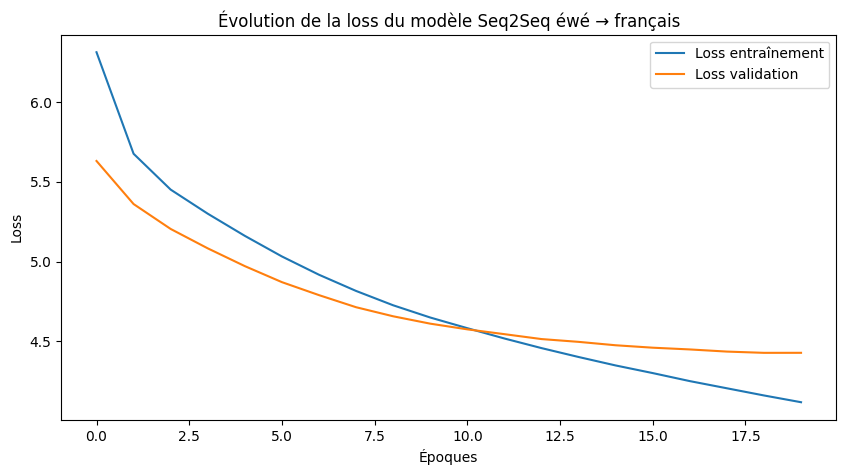

In [18]:
# On visualise l'évolution de la loss.
# Cela permet de voir si le modèle apprend correctement
# et si la validation commence à stagner.

plt.figure(figsize=(10, 5))
plt.plot(history.history["loss"], label="Loss entraînement")
plt.plot(history.history["val_loss"], label="Loss validation")
plt.title("Évolution de la loss du modèle Seq2Seq éwé → français")
plt.xlabel("Époques")
plt.ylabel("Loss")
plt.legend()
plt.show()

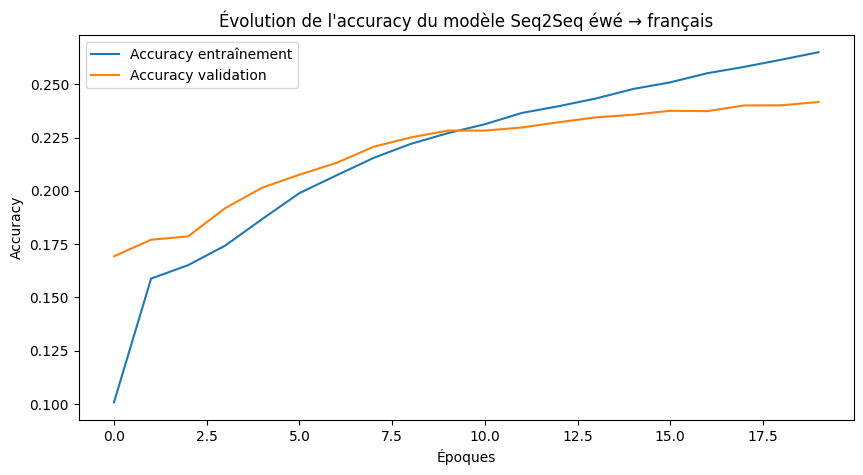

In [19]:
# On visualise l'évolution de l'accuracy mot par mot.
# Cette métrique donne une première idée de l'apprentissage,
# même si elle ne mesure pas parfaitement la qualité des traductions complètes.

plt.figure(figsize=(10, 5))
plt.plot(history.history["accuracy"], label="Accuracy entraînement")
plt.plot(history.history["val_accuracy"], label="Accuracy validation")
plt.title("Évolution de l'accuracy du modèle Seq2Seq éwé → français")
plt.xlabel("Époques")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [20]:
# On recharge le meilleur modèle sauvegardé par ModelCheckpoint,
# puis on l'évalue sur le jeu de test.

best_model = tf.keras.models.load_model(checkpoint_path)

test_loss, test_accuracy = best_model.evaluate(
    [X_test_ewe, decoder_input_test_fr],
    decoder_target_test_fr
)

print("Loss sur le test set :", test_loss)
print("Accuracy sur le test set :", test_accuracy)

74/74 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - accuracy: 0.2400 - loss: 4.4318
Loss sur le test set : 4.431832313537598
Accuracy sur le test set : 0.24001242220401764


In [21]:
# On sauvegarde aussi le modèle final dans Google Drive.

final_model_path = os.path.join(models_dir, "seq2seq_lstm_ewe_to_fr_final.keras")

model.save(final_model_path)

print("Modèle final sauvegardé ici :", final_model_path)

Modèle final sauvegardé ici : /content/drive/MyDrive/french_ewe_project/models/seq2seq_lstm_ewe_to_fr_final.keras


## Comparaison avec le modèle français → éwé

Nous disposons maintenant de deux modèles Seq2Seq LSTM :

| Direction | Loss test | Accuracy test |
|---|---:|---:|
| Français → Éwé | 4.7163 | 0.2576 |
| Éwé → Français | 4.4318 | 0.2400 |

Les deux modèles obtiennent des performances proches.  
Le modèle français → éwé obtient une accuracy légèrement plus élevée, tandis que le modèle éwé → français obtient une loss légèrement plus faible.

Ces résultats doivent être interprétés avec prudence, car l’accuracy mot par mot ne reflète pas toujours la qualité réelle d’une traduction complète.

## Conclusion

Dans ce notebook, nous avons entraîné un deuxième modèle Seq2Seq LSTM pour la traduction éwé → français.

Ce modèle complète le premier modèle français → éwé et permet d’avancer vers un système de traduction bidirectionnel.

Les résultats obtenus sur le jeu de test sont :

- Loss : 4.4318
- Accuracy mot par mot : 0.2400

Comme pour le premier modèle, cette accuracy correspond à une accuracy mot par mot. Elle permet de suivre l’apprentissage du modèle, mais elle ne suffit pas à mesurer parfaitement la qualité globale des traductions.

Ces résultats montrent que le modèle apprend certaines correspondances entre l’éwé et le français, mais ses performances restent limitées. Cela est cohérent avec la difficulté de la traduction automatique, la taille du corpus, l’absence de mécanisme d’attention et le fait que l’éwé soit une langue faiblement représentée dans les ressources NLP.

Ce modèle constitue donc une deuxième baseline Deep Learning. Il complète la première baseline français → éwé et servira de base pour des améliorations futures, comme l’ajout d’un mécanisme d’attention ou l’utilisation d’un modèle Transformer.

# Test de traduction avec le modèle éwé → français

Après l'entraînement et l'évaluation du modèle, nous testons maintenant sa capacité à générer une phrase française à partir d'une phrase en éwé.

Le modèle reçoit une phrase éwé en entrée, la transforme en séquence numérique, puis génère progressivement une phrase française en commençant par le token `<start>` jusqu’au token `<end>` ou jusqu’à la longueur maximale autorisée.

In [22]:
# On recharge le meilleur modèle éwé → français sauvegardé dans Google Drive.
# Cela permet d'utiliser le modèle le plus performant obtenu pendant l'entraînement.

best_model_path = os.path.join(models_dir, "best_seq2seq_ewe_to_fr.keras")

model = tf.keras.models.load_model(best_model_path)

print("Meilleur modèle éwé → français rechargé avec succès.")
print("Nom du modèle :", model.name)

Meilleur modèle éwé → français rechargé avec succès.
Nom du modèle : seq2seq_lstm_ewe_to_french


In [23]:
# Le tokenizer français transforme les mots en indices.
# Pour afficher une traduction lisible, on doit faire l'opération inverse :
# transformer les indices prédits en mots français.

reverse_french_word_index = {
    index: word for word, index in french_tokenizer.word_index.items()
}

In [24]:
import re

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"([?.!,¿])", r" \1 ", text)
    text = re.sub(r"\s+", " ", text)
    text = text.strip()
    return text

In [25]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np

def translate_ewe_to_fr(sentence):
    # On nettoie la phrase en éwé comme pendant le prétraitement.
    cleaned_sentence = clean_text(sentence)

    # On transforme la phrase en séquence numérique avec le tokenizer éwé.
    input_sequence = ewe_tokenizer.texts_to_sequences([cleaned_sentence])

    # On applique le padding pour obtenir la même longueur que pendant l'entraînement.
    input_sequence = pad_sequences(
        input_sequence,
        maxlen=MAX_LEN_EWE,
        padding="post",
        truncating="post"
    )

    # On récupère le token de début de phrase côté français.
    start_token = french_tokenizer.word_index.get("<start>")

    if start_token is None:
        return "Erreur : le token <start> n'existe pas dans le tokenizer français."

    # Le décodeur commence avec uniquement le token <start>.
    decoder_sequence = np.zeros((1, MAX_LEN_FRENCH - 1))
    decoder_sequence[0, 0] = start_token

    translated_words = []

    # Le modèle génère la traduction mot par mot.
    for i in range(1, MAX_LEN_FRENCH - 1):
        predictions = model.predict(
            [input_sequence, decoder_sequence],
            verbose=0
        )

        predicted_id = np.argmax(predictions[0, i - 1, :])
        predicted_word = reverse_french_word_index.get(predicted_id, "")

        if predicted_word == "<end>":
            break

        if predicted_word not in ["", "<start>", "<unk>"]:
            translated_words.append(predicted_word)

        decoder_sequence[0, i] = predicted_id

    return " ".join(translated_words)

In [26]:
# On charge le fichier test.csv depuis Google Drive.
# Cela permet de tester le modèle sur des phrases réellement présentes dans notre corpus.

processed_dir = os.path.join(project_dir, "data/processed")
test_df = pd.read_csv(os.path.join(processed_dir, "test.csv"))

test_df.head()

,french,ewe,source,type,french_length,ewe_length
0,"En Europe, la valeur limite de consommation de...","le yuropa la, fɔ̃nyinuɖuɖu ɖuɖu se ɖe miligraŋ...",https://l-frii.com/,News,15,13
1,Le calao qui ne sait ni nager ni pêcher ne tro...,Kalao yi matem aƒu tsi alo aɖe lã o la mega ny...,https://carnet-de-contes.jimdofree.com/contes/...,Tales,15,15
2,"Ensuite, elle avait rejoint les Etats Unis pou...",emegbea eva Amerika be yeasrɔ̃ tso gaŋutinyawo...,https://leschroniquesdetchonte.com/,Blog,13,8
3,"Dans €œSoufi, mon amour€_x009d_, j'en ai appri...","le «soufi mon amour» me la, mesrɔ̃nu kuɖe mɔsl...",https://leschroniquesdetchonte.com/,Blog,19,13
4,les parents se doivent d'être exemplaires et d...,to esiawo mee miate ŋu atrɔ ɖevi ade ƒe nɔnɔme,https://ellecitoyenne.com/,"Blog, News",19,10


In [27]:
# On teste quelques phrases éwé du jeu de test.
# Pour chaque exemple, on affiche :
# - la phrase éwé d'origine ;
# - la vraie traduction française ;
# - la traduction générée par le modèle.

for i in range(5):
    ewe_sentence = test_df.iloc[i]["ewe"]
    true_french = test_df.iloc[i]["french"]
    predicted_french = translate_ewe_to_fr(ewe_sentence)

    print("Éwé original       :", ewe_sentence)
    print("Français attendu   :", true_french)
    print("Français généré    :", predicted_french)
    print("-" * 100)

Éwé original       : le yuropa la, fɔ̃nyinuɖuɖu ɖuɖu se ɖe miligraŋu 100 le gbe ɖeka kol
Français attendu   : En Europe, la valeur limite de consommation de l’acide glycyrrhizique est limitée à 100 mg/jour
Français généré    : , , , , , ,
----------------------------------------------------------------------------------------------------
Éwé original       : Kalao yi matem aƒu tsi alo aɖe lã o la mega nya nusi woaɖu o.
Français attendu   : Le calao qui ne sait ni nager ni pêcher ne trouva donc plus à manger.
Français généré    : le est , il y a à la ,
----------------------------------------------------------------------------------------------------
Éwé original       : emegbea eva Amerika be yeasrɔ̃ tso gaŋutinyawo ŋui
Français attendu   : Ensuite, elle avait rejoint les Etats Unis pour préparer un diplôme en finances
Français généré    : il y a à la , et
----------------------------------------------------------------------------------------------------
Éwé original       : le «souf

## Analyse des traductions générées

Les tests réalisés sur quelques phrases du jeu de test montrent que le modèle peut générer des sorties en français, mais les traductions restent limitées.

Comme pour le modèle français → éwé, certaines sorties peuvent être incomplètes, répétitives ou trop générales. Cela s'explique par le fait que le modèle Seq2Seq LSTM utilisé ici reste une architecture simple, sans mécanisme d’attention ni modèle pré-entraîné.

Les résultats quantitatifs obtenus sur le jeu de test étaient :

- Loss : 4.4318
- Accuracy mot par mot : 0.2400

Ces résultats confirment que le modèle apprend certaines correspondances entre l’éwé et le français, mais qu’il ne produit pas encore des traductions fiables pour une utilisation réelle.

Cette étape reste néanmoins importante, car elle complète le système bidirectionnel :

- français → éwé ;
- éwé → français.

Les prochaines améliorations possibles sont l’ajout d’un mécanisme d’attention, l’utilisation d’un Transformer ou le fine-tuning d’un modèle multilingue pré-entraîné.